## Employee Attrition Prediction Using Machine Learning

Import Libraries

In [3]:
import pandas as pd
import numpy as np


Load Dataset

In [5]:
df = pd.read_csv("HR__Attrition.csv")

In [6]:
print("Rows and Coloumns :",df.shape)

Rows and Coloumns : (1470, 35)


In [7]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [11]:
attrition_rate = df["Attrition"].value_counts()["Yes"]/len(df)*100
print(f"percentage of employee leave the company : {attrition_rate:.2f}%")

percentage of employee leave the company : 16.12%


In [12]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [13]:
numeric_types = df.select_dtypes(include =["int64"]).columns
category_types = df.select_dtypes(include=["object"]).columns
print(f"numeric types : {len(numeric_types)}")
print(f"category types : {len(category_types)}")

numeric types : 26
category types : 9


The dataset contains 26 numerical columns and 9 categorical columns. The numerical columns include values such as Age, MonthlyIncome and so on, while the categorical columns include Department, JobRole, and Attrition

In [15]:
df = df.drop(columns=["EmployeeNumber" ,"Over18" ,"StandardHours"])

In [16]:
df.shape

(1470, 32)

In [17]:
print(df["EmployeeCount"].value_counts())

EmployeeCount
1    1470
Name: count, dtype: int64


In [18]:
df= df.drop(columns=["EmployeeCount"])

In [19]:
df.shape

(1470, 31)

In [20]:
df["Attrition"]=df["Attrition"].map({"Yes" : 1 , "No" : 0})

In [21]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

One-Hot Encoding converts categorical (text) features into binary numerical columns so that machine learning algorithms can process them without assuming any order among the categories.

In [23]:
df= pd.get_dummies(df, drop_first=True)
df.shape

(1470, 45)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = df.drop("Attrition",axis=1)
y = df["Attrition"]
x_scaled = scaler.fit_transform(x)

# 📊 Exploratory Data Analysis (EDA)

Attrition rate by Department

In [27]:
df_eda = pd.read_csv("HR__Attrition.csv")

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


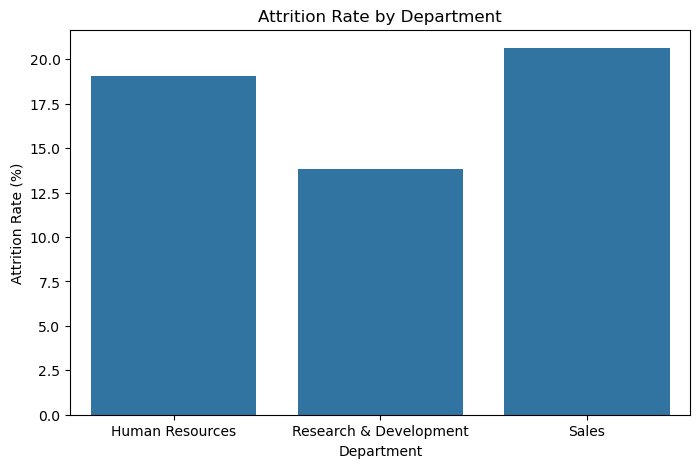

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

department_attrition = df_eda.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

print(department_attrition)

plt.figure(figsize=(8,5))
sns.barplot(x=department_attrition.index, y=department_attrition.values)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.savefig("AttritionRate_by_Department.png")
plt.show()

Observation: The Sales department has the highest attrition rate (around 20.6%), followed by Human Resources (around 19%). Research & Development has the lowest attrition rate (around 13.8%). This suggests that HR should prioritize employee retention efforts in the Sales department.

Attrition Rate by Job Role

JobRole
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: Attrition, dtype: float64


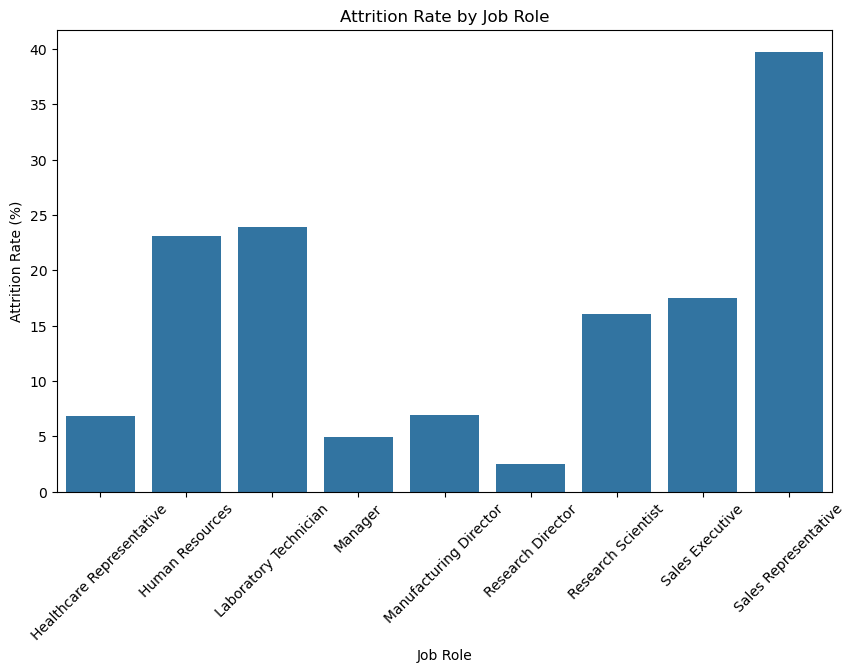

In [110]:
jobrole_attrition = df_eda.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

print(jobrole_attrition)

plt.figure(figsize=(10,6))
sns.barplot(x=jobrole_attrition.index, y=jobrole_attrition.values)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)

plt.savefig("AttritionRate_by_JobRole.png")
plt.show()

Observation: The Sales Representative role has the highest attrition rate at 39.75%, indicating that employees in this role are more likely to leave the company. In contrast, the Research Director role has the lowest attrition rate at 2.5%, suggesting better employee retention. HR should focus on understanding and addressing the reasons behind the high turnover among Sales Representatives.

Attrition vs Monthly Income

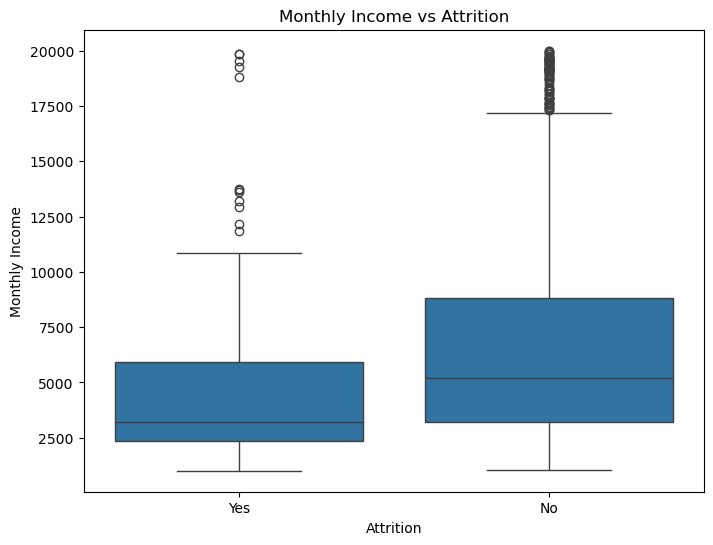

In [112]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df_eda)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.savefig("MonthlyIncome_vs_Attrition.png")
plt.show()

Observation: The box plot shows that employees who left the company (Attrition = Yes) generally had lower monthly incomes than employees who stayed (Attrition = No). The median monthly income for employees who left is lower, suggesting that salary may be one of the factors influencing employee attrition.

Attrition vs Work-Life Balance

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


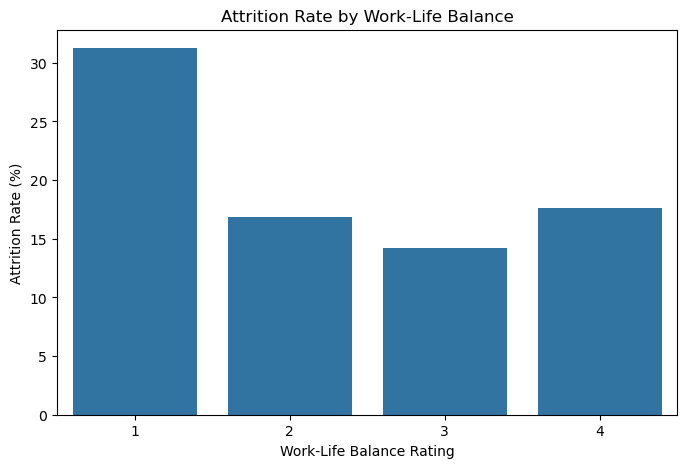

In [114]:
worklife_attrition = df_eda.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

print(worklife_attrition)

plt.figure(figsize=(8,5))
sns.barplot(x=worklife_attrition.index, y=worklife_attrition.values)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.savefig("AttritionRate_by_Work-Life-Balance.png")
plt.show()

Observation: Employees with a Work-Life Balance rating of 1 have the highest attrition rate (31.25%). This indicates that poor work-life balance is strongly associated with employees leaving the company. As work-life balance improves, the attrition rate generally decreases.

Attrition vs Years at Company

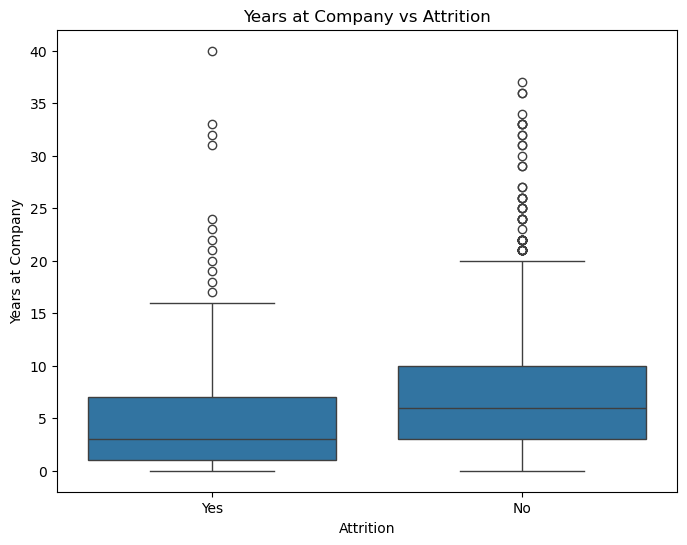

In [40]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Attrition", y="YearsAtCompany", data=df_eda)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.savefig("YearsAtCompany_vs_Attrition.png")
plt.show()

Observation: The box plot shows that employees who left the company generally had slightly fewer years at the company than those who stayed. However, the difference in the median years is relatively small, suggesting that years at the company alone is not a strong predictor of employee attrition.

Train-Test Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1176, 44)
Testing Features: (294, 44)
Training Labels: (1176,)
Testing Labels: (294,)


## 🤖 Model 1: Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.8809523809523809


In [48]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.56      0.46      0.51        39

    accuracy                           0.88       294
   macro avg       0.74      0.70      0.72       294
weighted avg       0.87      0.88      0.88       294



In [49]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[241  14]
 [ 21  18]]


Observation: The Logistic Regression model achieved an accuracy of 88.09%. It performed very well in identifying employees who stayed (Precision: 92%, Recall: 95%). However, its performance in identifying employees who left was lower (Precision: 56%, Recall: 46%), indicating that some employees who actually left were not detected by the model.

## 🌳Model 2: Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8775510204081632


In [54]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [55]:
print(confusion_matrix(y_test, y_pred_rf))

[[254   1]
 [ 35   4]]


Observation: The Random Forest model achieved an accuracy of 87.76%. It performed exceptionally well in predicting employees who stayed (Recall: 100%), but its ability to identify employees who left was poor (Recall: 10%). Although the model had high precision (80%) for predicting employee attrition, it missed many employees who actually left. Therefore, for this dataset, Logistic Regression performed better overall in identifying employee attrition.

## 🤖 Model 3: Gradient Boosting Classifier

In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)


Gradient Boosting Accuracy: 0.8707482993197279


In [60]:
print(classification_report(y_test, y_pred_gb))


              precision    recall  f1-score   support

           0       0.89      0.98      0.93       255
           1       0.54      0.18      0.27        39

    accuracy                           0.87       294
   macro avg       0.71      0.58      0.60       294
weighted avg       0.84      0.87      0.84       294



In [61]:
print(confusion_matrix(y_test, y_pred_gb))

[[249   6]
 [ 32   7]]


Observation: The Gradient Boosting model achieved an accuracy of 87.07%. It performed well in identifying employees who stayed but showed limited performance in detecting employees who left. The model achieved a recall of 18% for attrition, indicating that many employees who actually left were not identified. Overall, its performance was lower than Logistic Regression on this dataset.

## Model Comparison

| Model | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) |
|--------|---------:|--------------------:|-----------------:|-------------------:|
| Logistic Regression | **88.09%** | **56%** | **46%** | **51%** |
| Random Forest | 87.76% | **80%** | 10% | 18% |
| Gradient Boosting | 87.07% | 54% | 18% | 27% |

The performance of three machine learning models was compared using Accuracy, Precision, Recall, and F1-score. Logistic Regression achieved the highest accuracy (88.09%) and the highest recall (46%) for predicting employee attrition. Although Random Forest had higher precision (80%), it identified only 10% of employees who actually left. Gradient Boosting also showed lower recall (18%) and accuracy (87.07%). Therefore, Logistic Regression was selected as the best-performing model for this employee attrition prediction task.

## 🎯 Final Conclusion

This project focused on predicting employee attrition using machine learning techniques. After preprocessing the data and performing exploratory data analysis, three classification models were developed: Logistic Regression, Random Forest, and Gradient Boosting.

The performance of the models was evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Among the three models, Logistic Regression performed the best with an accuracy of 88.09% and a recall of 46% for predicting employee attrition. Since the main objective is to identify employees who are likely to leave, Logistic Regression proved to be the most suitable model for this dataset.

The analysis also showed that factors such as department, job role, monthly income, and work-life balance influence employee attrition. These insights can help HR departments take proactive steps to improve employee retention.